In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from dataset_generation import generate_dataset, sm_generative_model, kfold_dataset
from wassa_plots import plot_SM, plot_colored_raster, plot_results
from wassa_training import learn_motifs
from wassa import WassA

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Generative model for raster plots and spiking motifs

List of parameters for this generative model

In [4]:
dataset_parameters = {
    'seed' : 81,
    
    'N_pre' : 100, # number of neurons
    'N_timesteps' : 1000, # number of timesteps for the raster plot (in ms)
    'N_samples' : 100, # total number of samples in the dataset

    'N_delays' : 51, # number of timesteps in spiking motifs, must be a odd number for convolutions
    'N_SMs' : 3, # number of structured spiking motifs
    'avg_fr' : 20, # average firing rate of the neurons (in Hz)
    'std_fr' : .1, # standard deviation for the firing rates of the different neurons
    'overlapping_sms' : False, # possibility to have overlapping sequences

    'temporal_jitter' : 1, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'warping_coef' : 1, # coefficient for time warping

}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_SMs'],device=device)}) # number of neurons involved in the spiking motif
dataset_parameters.update({'frs' : torch.normal(dataset_parameters['avg_fr'], dataset_parameters['std_fr'], size=(dataset_parameters['N_pre'],)).abs()})
dataset_parameters.update({'freq_sms' : 4*torch.ones(dataset_parameters['N_SMs'],device=device)}) # frequency of apparition of the different spiking motifs (in Hz)
dataset_parameters.update({'coefficient_variation' : 1*torch.ones(dataset_parameters['N_pre'],device=device)}) # coefficient of variation of the FRs of each neuron (within VS. without a motif)

In [5]:
sm = sm_generative_model(dataset_parameters, device=device)

The generative model will draw raster plots generated from both a spontaneous (random) activity and from spiking motifs. There are *parameters.N_SM* spiking motifs represented in the next plot. There are given as a spiking probability for each presynatpic neuron and each timestep (or delay). 

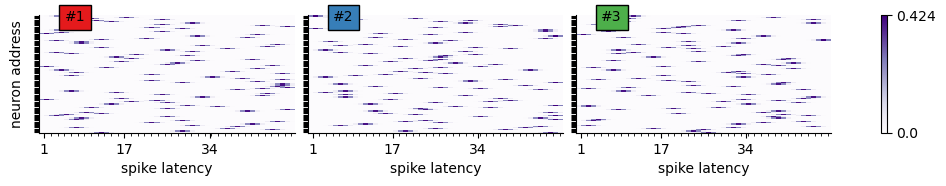

In [6]:
plot_SM(sm.SMs);

The raster plot is produced with a sequence of apparition of the different motifs and random activity when no motif occurs. 

In [7]:
input_rp, output_rp = sm.draw_input(nb_trials=dataset_parameters['N_samples'])

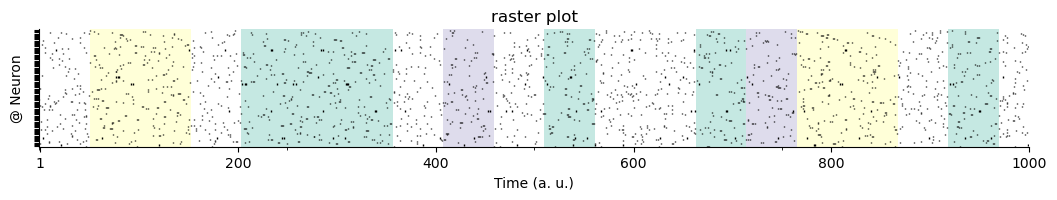

In [8]:
random_ind = torch.randint(dataset_parameters['N_samples'],[1],device=device)
plot_colored_raster(input_rp[random_ind].cpu().squeeze(0), output_rp[random_ind].cpu().squeeze(0), dataset_parameters['N_delays'], dataset_parameters['warping_coef']);

In [9]:
training_parameters = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_delays']),
    'loss_type' : 'emd',
    'topk' : None,
    'N_learnsteps' : 1000,
    'learning_rate' : .01,
    'beta_1' : .9,
    'penalty_type' : ['max_cc'],
    'smoothwind' : 0,
    'expected_patterns_per_sample' : dataset_parameters['N_timesteps']*dataset_parameters['freq_sms'][0]*1e-3,
    'lambda' : [.06],
    'batch_size' : 20,
    'do_bias' : [False,False,False],
    'kernels_norm' : 1,
    'tied_weights' : True,
    'weight_init' : None,
    'normalize_input' : True,
    'reshape_input': True}

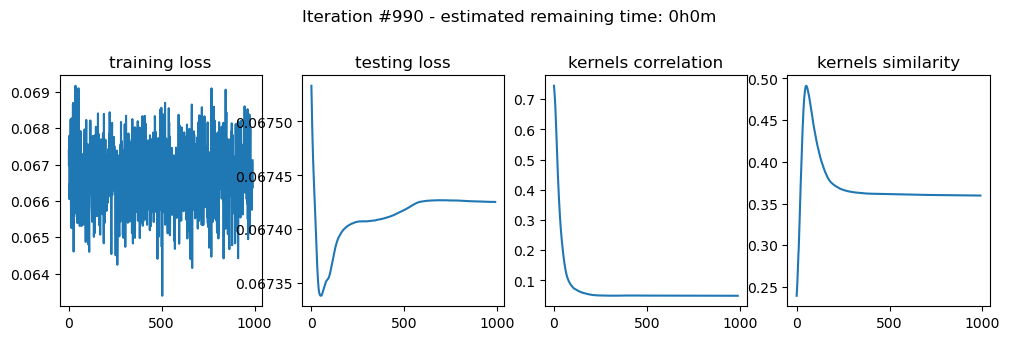

In [10]:
plot_during_training = True
training_sets, testing_sets, _ = kfold_dataset(input_rp)
model_path = '../results/tuto_lr_.01_3_càc.006_jitkter_batch'
training_metrics = ['training loss', 'testing loss', 'kernels correlation', 'kernels similarity']
autoencoder = WassA(training_parameters, device=device)
trained_autoencoder, training_metrics, metric_names = learn_motifs(autoencoder,training_sets[0],testing_sets[0],training_parameters,model_path,training_metrics,sm=sm,online_plots=plot_during_training)

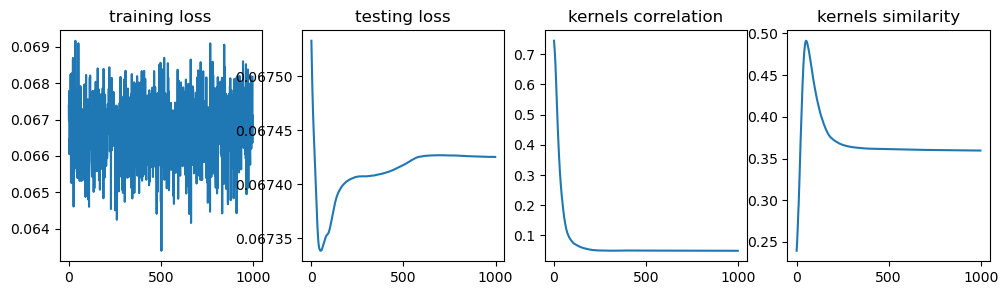

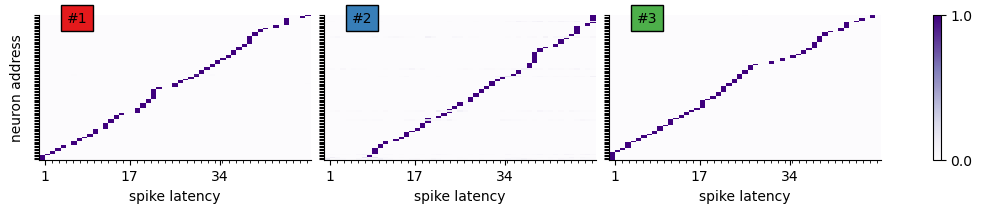

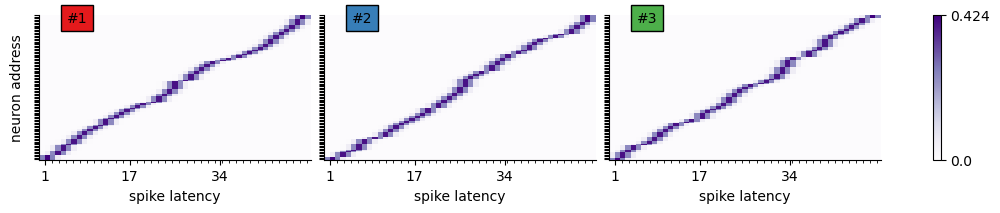

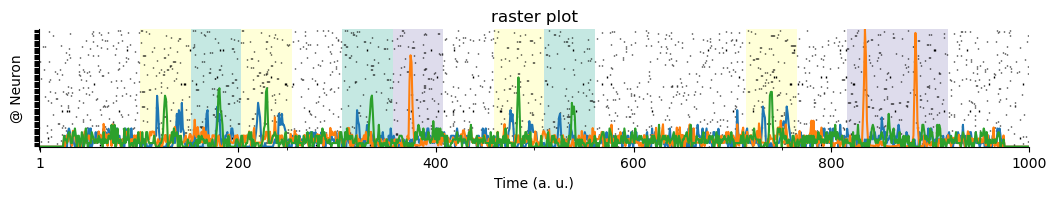

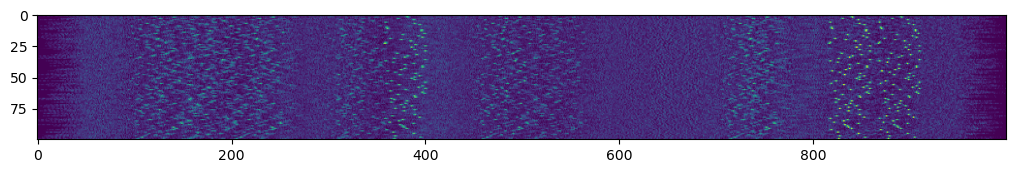

In [11]:
plot_results(training_metrics, metric_names, trained_autoencoder, input_rp, true_occurence=output_rp, true_weights=sm.SMs, order_sms = True)